# 6CS012 – Worksheet 4
## Building a Fully Connected Neural Network for Devnagari Handwritten Digit Classification

**Tasks covered:** Data Preparation → Build FCN → Compile → Train → Evaluate → Save/Load → Predict

---
## Task 1: Data Preparation
Load images from the dataset folder using PIL, normalize pixel values, and one-hot encode labels.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import zipfile, os, shutil

# Path to your zip in Google Drive
zip_path = "/content/drive/MyDrive/AI and Machine Learning/Copy of devnagari digit.zip"

# Extract to current Colab directory
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content/")

print("Extracted successfully!")
print(os.listdir("/content/DevanagariHandwrittenDigitDataset"))

Extracted successfully!
['Train', 'Test']


Loading training images …
Loading test images …

Training set : (17000, 784)  |  Labels: (17000, 10)
Test set     : (3000, 784)   |  Labels: (3000, 10)


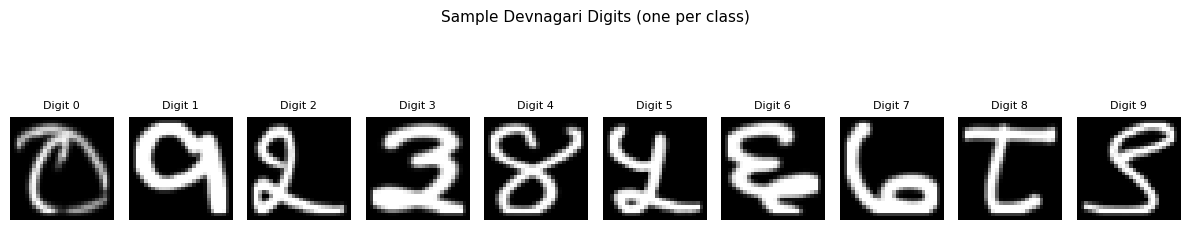

In [20]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

# ── Dataset paths ──────────────────────────────────────────────────────────────
train_dir = "/content/DevanagariHandwrittenDigitDataset/Train/"
test_dir  = "/content/DevanagariHandwrittenDigitDataset/Test/"

# ── Image dimensions ───────────────────────────────────────────────────────────
IMG_HEIGHT, IMG_WIDTH = 28, 28
NUM_CLASSES = 10

# ── Helper: load all images from a folder ──────────────────────────────────────
def load_images_from_folder(folder):
    """Load images + labels from a directory with sub-folders per class."""
    images, labels = [], []

    # Sort so that digit_0 → 0, digit_1 → 1, …, digit_9 → 9
    class_names = sorted(os.listdir(folder))
    class_map   = {name: idx for idx, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue                          # skip stray files
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            img = Image.open(img_path).convert("L")              # grayscale
            img = img.resize((IMG_WIDTH, IMG_HEIGHT))            # 28×28
            img = np.array(img) / 255.0                          # normalise [0,1]
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

print("Loading training images …")
x_train_raw, y_train_raw = load_images_from_folder(train_dir)

print("Loading test images …")
x_test_raw,  y_test_raw  = load_images_from_folder(test_dir)

# ── Flatten for FCN: (N, 28, 28) → (N, 784) ───────────────────────────────────
x_train = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)
x_test  = x_test_raw.reshape( -1, IMG_HEIGHT * IMG_WIDTH)

# ── One-hot encode labels ──────────────────────────────────────────────────────
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f"\nTraining set : {x_train.shape}  |  Labels: {y_train.shape}")
print(f"Test set     : {x_test.shape}   |  Labels: {y_test.shape}")

# ── Visualise a sample of 10 training images ───────────────────────────────────
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train_raw[i * 1700], cmap="gray")   # one image per class
    plt.title(f"Digit {i}", fontsize=8)
    plt.axis("off")
plt.suptitle("Sample Devnagari Digits (one per class)", fontsize=11)
plt.tight_layout()
plt.show()

In [21]:
import os

zip_file_url = "YOUR_DATASET_ZIP_URL" # Example: "https://github.com/some_user/some_repo/raw/main/DevanagariHandwrittenDigitDataset.zip"
zip_file_name = "DevanagariHandwrittenDigitDataset.zip"

# If you are providing a URL, uncomment the line below:
# !wget -O {zip_file_name} {zip_file_url}

# If you have uploaded the zip file manually to the Colab environment, just ensure it's in the current directory.

print(f"Checking for {zip_file_name}...")
if os.path.exists(zip_file_name):
    print(f"{zip_file_name} found.")
else:
    print(f"WARNING: {zip_file_name} not found. Please upload it or provide a valid download URL.")

Checking for DevanagariHandwrittenDigitDataset.zip...


In [22]:
import os

zip_file_name = "DevanagariHandwrittenDigitDataset.zip"
destination_folder = "DevanagariHandwrittenDigitDataset"

if os.path.exists(zip_file_name):
    print(f"Unzipping {zip_file_name}...")
    !unzip -q {zip_file_name} -d {destination_folder}
    print(f"Dataset unzipped to {destination_folder}/")

    # Verify contents
    if os.path.exists(os.path.join(destination_folder, 'Train')):
        print("Train directory found within unzipped dataset.")
    else:
        print("WARNING: Train directory not found in the unzipped dataset. Check the zip file structure.")

    if os.path.exists(os.path.join(destination_folder, 'Test')):
        print("Test directory found within unzipped dataset.")
    else:
        print("WARNING: Test directory not found in the unzipped dataset. Check the zip file structure.")

else:
    print(f"Skipping unzip: {zip_file_name} not found. Please ensure the zip file is present.")

Skipping unzip: DevanagariHandwrittenDigitDataset.zip not found. Please ensure the zip file is present.


In [23]:
train_dir = "DevanagariHandwrittenDigitDataset/Train/"
test_dir  = "DevanagariHandwrittenDigitDataset/Test/"

print(f"train_dir is set to: {train_dir}")
print(f"test_dir is set to: {test_dir}")

train_dir is set to: DevanagariHandwrittenDigitDataset/Train/
test_dir is set to: DevanagariHandwrittenDigitDataset/Test/


---
## Task 2: Build the FCN Model
Sequential model with 3 hidden layers (64 → 128 → 256 neurons, sigmoid activation) and a softmax output layer.

In [24]:
from tensorflow import keras
from tensorflow.keras import layers

# ── Model definition ───────────────────────────────────────────────────────────
model = keras.Sequential(
    [
        keras.Input(shape=(IMG_HEIGHT * IMG_WIDTH,)),   # 784-dim input vector

        # Hidden layer 1
        layers.Dense(64,  activation="sigmoid", name="hidden_1"),

        # Hidden layer 2
        layers.Dense(128, activation="sigmoid", name="hidden_2"),

        # Hidden layer 3
        layers.Dense(256, activation="sigmoid", name="hidden_3"),

        # Output layer – 10 classes, probabilities via softmax
        layers.Dense(NUM_CLASSES, activation="softmax", name="output"),
    ],
    name="Devnagari_FCN"
)

model.summary()

Model: "Devnagari_FCN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

---
## Task 3: Compile the Model
Use Adam optimiser, categorical cross-entropy loss (labels are one-hot encoded), and accuracy metric.

In [25]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",   # one-hot encoded labels → categorical
    metrics=["accuracy"]
)

print("Model compiled successfully!")
print(f"  Optimizer : adam")
print(f"  Loss      : categorical_crossentropy")
print(f"  Metrics   : accuracy")

Model compiled successfully!
  Optimizer : adam
  Loss      : categorical_crossentropy
  Metrics   : accuracy


---
## Task 4: Train the Model
Train for up to 20 epochs (batch size = 128, 20 % validation split).  
Callbacks: **ModelCheckpoint** saves the best weights; **EarlyStopping** halts training if val_loss stops improving.

In [26]:
BATCH_SIZE = 128
EPOCHS     = 20

# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_devnagari_model.keras",   # saves the BEST model (lowest val_loss)
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,                              # stop after 4 epochs with no improvement
        restore_best_weights=True,
        verbose=1
    ),
]

# ── Train ──────────────────────────────────────────────────────────────────────
history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,     # 20% of training data used for validation
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")

Epoch 1/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2874 - loss: 1.9731
Epoch 1: val_loss improved from None to 7.12287, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4854 - loss: 1.6088 - val_accuracy: 0.0000e+00 - val_loss: 7.1229
Epoch 2/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7981 - loss: 0.6448
Epoch 2: val_loss did not improve from 7.12287
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8401 - loss: 0.5154 - val_accuracy: 0.0000e+00 - val_loss: 8.2756
Epoch 3/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9125 - loss: 0.3098
Epoch 3: val_loss did not improve from 7.12287
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9233 - loss: 0.2756 - val_accuracy: 0.0000e+00 - val_loss: 8.7751
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9491 - loss: 0.1913
Epoch 4: val_loss did not improve from 7.122

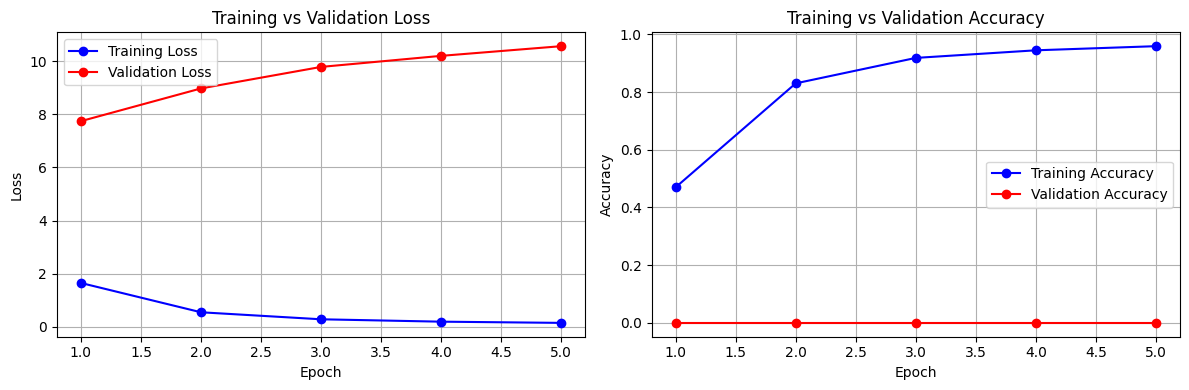

Training curves saved to training_curves.png


In [15]:
# ── Visualise training progress ────────────────────────────────────────────────
train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]
train_acc  = history.history["accuracy"]
val_acc    = history.history["val_accuracy"]
epochs_ran = range(1, len(train_loss) + 1)

plt.figure(figsize=(12, 4))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(epochs_ran, train_loss, "b-o", label="Training Loss")
plt.plot(epochs_ran, val_loss,   "r-o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(epochs_ran, train_acc, "b-o", label="Training Accuracy")
plt.plot(epochs_ran, val_acc,   "r-o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Training curves saved to training_curves.png")

---
## Task 5: Evaluate the Model
Measure the final loss and accuracy on the held-out **test set**.

In [16]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"\n{'='*40}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc * 100:.2f} %")
print(f"{'='*40}")

94/94 - 0s - 3ms/step - accuracy: 0.6077 - loss: 2.2436

  Test Loss     : 2.2436
  Test Accuracy : 60.77 %


---
## Task 6: Save and Load the Model
Persist the trained model to disk in `.h5` format, reload it, and verify it still achieves the same accuracy.

In [17]:
# ── Save ──────────────────────────────────────────────────────────────────────
MODEL_PATH = "devnagari_fcn_model.h5"
model.save(MODEL_PATH)
print(f"Model saved → {MODEL_PATH}")

Model saved → devnagari_fcn_model.h5


In [28]:
# ── Load and re-evaluate ──────────────────────────────────────────────────────
loaded_model = tf.keras.models.load_model(MODEL_PATH)
print(f"Model loaded from {MODEL_PATH}")

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"\nLoaded model – Test Accuracy: {loaded_acc * 100:.2f} %")

Model loaded from devnagari_fcn_model.h5
94/94 - 1s - 6ms/step - accuracy: 0.6077 - loss: 2.2436

Loaded model – Test Accuracy: 60.77 %


---
## Task 7: Make Predictions
Run the model on the test set, convert softmax probabilities to digit labels, and display a grid of results.

Sample predictions (first 5 test images):
  Predicted : [0 0 0 0 0]
  True      : [0 0 0 0 0]


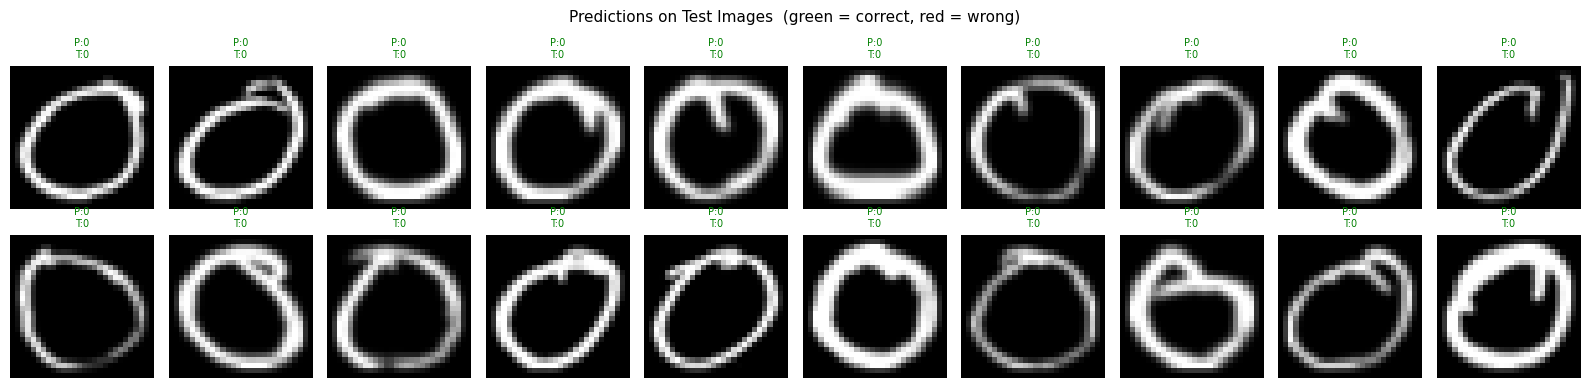

Prediction grid saved to predictions_grid.png


In [27]:
# ── Predict ───────────────────────────────────────────────────────────────────
predictions      = loaded_model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)   # highest-probability class
true_labels      = np.argmax(y_test, axis=1)

# Quick sanity check on the first 5 samples
print("Sample predictions (first 5 test images):")
print(f"  Predicted : {predicted_labels[:5]}")
print(f"  True      : {true_labels[:5]}")

# ── Visualise 20 predictions ──────────────────────────────────────────────────
plt.figure(figsize=(16, 4))
for i in range(20):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test_raw[i], cmap="gray")
    colour = "green" if predicted_labels[i] == true_labels[i] else "red"
    plt.title(f"P:{predicted_labels[i]}\nT:{true_labels[i]}",
              fontsize=7, color=colour)
    plt.axis("off")

plt.suptitle("Predictions on Test Images  (green = correct, red = wrong)",
             fontsize=11)
plt.tight_layout()
plt.savefig("predictions_grid.png", dpi=150)
plt.show()
print("Prediction grid saved to predictions_grid.png")

---
## Summary

| Step | Detail |
|------|--------|
| Dataset | Devnagari Handwritten Digits – 17 000 train / 3 000 test |
| Input | 28 × 28 grayscale → flattened to 784-dim vector |
| Architecture | Dense(64, sigmoid) → Dense(128, sigmoid) → Dense(256, sigmoid) → Dense(10, softmax) |
| Optimiser | Adam |
| Loss | Categorical Cross-Entropy |
| Epochs | 20 (with EarlyStopping, patience=4) |
| Batch size | 128 |
| Validation split | 20 % |
| Saved model | `devnagari_fcn_model.h5` |